# State of Charge (SOC) Estimation using Deep Learning on Oxford Battery Degradation Dataset (LCO)

This notebook presents deep learning based State of Charge (SOC) estimation using the Oxford Battery Degradation Dataset 1.

The Oxford dataset contains commercial lithium-ion pouch cells with a Lithium Cobalt Oxide (LCO)-based cathode chemistry subjected to repeated charge-discharge cycling under controlled laboratory conditions.

Voltage, current and temperature measurements are utilized to estimate the battery State of Charge (SOC) using Long Short-Term Memory (LSTM) and Gated Recurrent Unit (GRU) deep learning models.

The objective of this work is to evaluate the feasibility of extending the same SOC estimation framework previously implemented on NASA, HUST, Tongji, and LG HG2 datasets to LCO battery chemistry.

## Dataset Description

Dataset : Oxford Battery Degradation Dataset 1

Institution : University of Oxford

Battery Type : Commercial Lithium-ion Pouch Cell

Cathode Chemistry : Lithium Cobalt Oxide (LCO)

Cell Format : Pouch Cell

File Format : MATLAB (.mat)

Target Variable : State of Charge (SOC)

Input Features :
- Voltage
- Current
- Temperature

Deep Learning Models :
- LSTM
- GRU

## Workflow

The complete pipeline consists of the following stages:

1. Load Oxford MATLAB dataset
2. Explore dataset structure
3. Extract Voltage, Current and Temperature measurements
4. Calculate State of Charge (SOC)
5. Data preprocessing and normalization
6. Generate sequential samples
7. Train LSTM model
8. Train GRU model
9. Evaluate model performance
10. Visualize predictions and compare results

In [1]:
#import dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import loadmat

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense

### Load Oxford Battery Degradation Dataset

The Oxford Battery Degradation Dataset is provided in MATLAB (.mat) format. This section loads the dataset and inspects its internal structure before extracting the required features for SOC estimation.

In [3]:
# loading the dataset
from scipy.io import loadmat

mat = loadmat(
    r"C:\Users\shrij\Downloads\Oxford_Battery_Degradation_Dataset_1"
)

print(mat.keys())

dict_keys(['__header__', '__version__', '__globals__', 'Cell1', 'Cell2', 'Cell3', 'Cell4', 'Cell5', 'Cell6', 'Cell7', 'Cell8'])


In [4]:
print(type(mat))

<class 'dict'>


In [5]:
for key in mat.keys():
    print(key)

__header__
__version__
__globals__
Cell1
Cell2
Cell3
Cell4
Cell5
Cell6
Cell7
Cell8


In [6]:
for key in mat.keys():
    if "__" not in key:
        print(key)
        print(type(mat[key]))
        print()

Cell1
<class 'numpy.ndarray'>

Cell2
<class 'numpy.ndarray'>

Cell3
<class 'numpy.ndarray'>

Cell4
<class 'numpy.ndarray'>

Cell5
<class 'numpy.ndarray'>

Cell6
<class 'numpy.ndarray'>

Cell7
<class 'numpy.ndarray'>

Cell8
<class 'numpy.ndarray'>



In [8]:
cell = mat['Cell1']

print(type(cell))
print(cell.shape)
print(cell.dtype)

<class 'numpy.ndarray'>
(1, 1)
[('cyc0000', 'O'), ('cyc0100', 'O'), ('cyc0200', 'O'), ('cyc0300', 'O'), ('cyc0400', 'O'), ('cyc0500', 'O'), ('cyc0600', 'O'), ('cyc0700', 'O'), ('cyc0800', 'O'), ('cyc0900', 'O'), ('cyc1000', 'O'), ('cyc1100', 'O'), ('cyc1200', 'O'), ('cyc1300', 'O'), ('cyc1400', 'O'), ('cyc1600', 'O'), ('cyc1800', 'O'), ('cyc1900', 'O'), ('cyc2000', 'O'), ('cyc2100', 'O'), ('cyc2200', 'O'), ('cyc2300', 'O'), ('cyc2400', 'O'), ('cyc2500', 'O'), ('cyc2600', 'O'), ('cyc2700', 'O'), ('cyc2800', 'O'), ('cyc2900', 'O'), ('cyc3000', 'O'), ('cyc3100', 'O'), ('cyc3200', 'O'), ('cyc3300', 'O'), ('cyc3500', 'O'), ('cyc3600', 'O'), ('cyc3700', 'O'), ('cyc3800', 'O'), ('cyc3900', 'O'), ('cyc4000', 'O'), ('cyc4100', 'O'), ('cyc4200', 'O'), ('cyc4300', 'O'), ('cyc4400', 'O'), ('cyc4500', 'O'), ('cyc4600', 'O'), ('cyc4800', 'O'), ('cyc5000', 'O'), ('cyc5100', 'O'), ('cyc5200', 'O'), ('cyc5300', 'O'), ('cyc5400', 'O'), ('cyc5500', 'O'), ('cyc5600', 'O'), ('cyc5700', 'O'), ('cyc5800', 'O

#### Inspect Battery Cycle Data

Each battery cell contains multiple cycle measurements stored independently. A representative cycle is explored to identify the available electrical measurements required for SOC estimation.

In [10]:
cycle = cell['cyc0000'][0,0]

print(type(cycle))
print(cycle.shape)
print(cycle.dtype)

<class 'numpy.ndarray'>
(1, 1)
[('C1ch', 'O'), ('C1dc', 'O'), ('OCVch', 'O'), ('OCVdc', 'O')]


In [11]:
print(cycle.dtype.names)

('C1ch', 'C1dc', 'OCVch', 'OCVdc')


In [12]:
print(type(cycle['C1ch'][0,0]))
print(cycle['C1ch'][0,0].shape)

try:
    print(cycle['C1ch'][0,0].dtype)
except:
    pass

<class 'numpy.ndarray'>
(1, 1)
[('t', 'O'), ('v', 'O'), ('q', 'O'), ('T', 'O')]


In [13]:
print(cycle['C1ch'][0,0])

[[(array([[735954.85896553],
         [735954.8589771 ],
         [735954.85898867],
         ...,
         [735954.8995558 ],
         [735954.89956738],
         [735954.8995751 ]]), array([[2.7192132],
         [2.8561351],
         [2.8771081],
         ...,
         [4.1993356],
         [4.1995358],
         [4.1999769]]), array([[-4.88295559e-05],
         [ 2.06338832e-01],
         [ 4.12724138e-01],
         ...,
         [ 7.23776940e+02],
         [ 7.23983220e+02],
         [ 7.24120891e+02]]), array([[41.295536],
         [41.000046],
         [40.962608],
         ...,
         [40.101341],
         [40.151283],
         [40.113808]]))                          ]]


In [14]:
c1 = cycle['C1ch'][0,0]

print("Time Shape:", c1['t'][0,0].shape)
print("Voltage Shape:", c1['v'][0,0].shape)
print("Capacity Shape:", c1['q'][0,0].shape)
print("Temperature Shape:", c1['T'][0,0].shape)

Time Shape: (3510, 1)
Voltage Shape: (3510, 1)
Capacity Shape: (3510, 1)
Temperature Shape: (3510, 1)


In [15]:
print(c1['v'][0,0][:5])

print(c1['q'][0,0][:5])

print(c1['T'][0,0][:5])

[[2.7192132]
 [2.8561351]
 [2.8771081]
 [2.8929081]
 [2.9063823]]
[[-4.88295559e-05]
 [ 2.06338832e-01]
 [ 4.12724138e-01]
 [ 6.19110452e-01]
 [ 8.25497243e-01]]
[[41.295536]
 [41.000046]
 [40.962608]
 [40.987579]
 [41.049992]]


### Summary of Dataset Exploration

The Oxford Battery Degradation Dataset is organized hierarchically. The MATLAB file contains data from multiple battery cells (Cell11–Cell18), where each cell consists of measurements recorded at different degradation stages (e.g., cyc0000, cyc0100, ..., cyc8200).

Each cycle stores four measurement groups:

- **C1ch** : Constant-current/constant-voltage charging data
- **C1dc** : Constant-current discharge data
- **OCVch** : Open-circuit voltage during charging
- **OCVdc** : Open-circuit voltage during discharging

The charging data (**C1ch**) contains the following variables:

- **t** : Time
- **v** : Voltage
- **q** : Capacity
- **T** : Temperature

During inspection, each variable was found to contain **3510 samples** for the selected cycle, confirming that all measurements are synchronized and suitable for building a time-series dataset.

Unlike previous datasets (NASA, HUST, Tongji, and LG HG2), this dataset does not explicitly store current measurements. This is expected because the cells were tested under controlled constant-current charging/discharging protocols, making the current effectively fixed during each experiment.

Therefore, the deep learning models will primarily utilize:

- Voltage
- Temperature
- Capacity (for SOC calculation)

These measurements are sufficient to investigate the feasibility of deep learning based State of Charge (SOC) estimation for Lithium Cobalt Oxide (LCO) battery chemistry.

> **Observation**
>
> The Oxford dataset follows a clean hierarchical organization (Cell → Cycle → Measurement Type → Variables), making it straightforward to automate data extraction across multiple battery cells. This structure is well suited for building a scalable preprocessing pipeline for deep learning based SOC estimation.


#### Create DataFrame from Charge Measurements

After identifying the available variables, the charging measurements are converted into a structured pandas DataFrame.

Each observation contains:

- Time
- Voltage
- Capacity
- Temperature

Organizing the measurements into a DataFrame simplifies preprocessing, visualization, feature engineering, and preparation for deep learning based SOC estimation.

In [16]:
df = pd.DataFrame({
    "Time": c1['t'][0,0].flatten(),
    "Voltage": c1['v'][0,0].flatten(),
    "Capacity": c1['q'][0,0].flatten(),
    "Temperature": c1['T'][0,0].flatten()
})

df.head()

,Time,Voltage,Capacity,Temperature
0,735954.858966,2.719213,-0.000049,41.295536
1,735954.858977,2.856135,0.206339,41.000046
2,735954.858989,2.877108,0.412724,40.962608
3,735954.859000,2.892908,0.619110,40.987579
4,735954.859012,2.906382,0.825497,41.049992


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3510 entries, 0 to 3509
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Time         3510 non-null   float64
 1   Voltage      3510 non-null   float64
 2   Capacity     3510 non-null   float64
 3   Temperature  3510 non-null   float64
dtypes: float64(4)
memory usage: 109.8 KB


In [18]:
df.describe()

,Time,Voltage,Capacity,Temperature
count,3510.000000,3510.000000,3510.000000,3510.000000
mean,735954.879272,3.819664,362.101645,40.049519
std,0.011729,0.221073,209.148607,0.321382
min,735954.858966,2.719213,-0.000049,39.314987
25%,735954.869119,3.728945,181.050787,39.839233
50%,735954.879272,3.830041,362.101557,40.138779
75%,735954.889426,3.962065,543.153139,40.251133
max,735954.899575,4.199977,724.120891,41.295536


#### Observation

The extracted charging measurements were successfully converted into a pandas DataFrame.

The dataset contains synchronized time-series observations for voltage, capacity, and temperature, making it suitable for sequential deep learning models such as LSTM and GRU.

No missing values or structural inconsistencies were observed during the initial inspection.

#### Exploratory Data Analysis (EDA)

Before training deep learning models, it is important to understand the behavior of the battery measurements.

The following plots illustrate how voltage, capacity, and temperature evolve throughout the charging process.

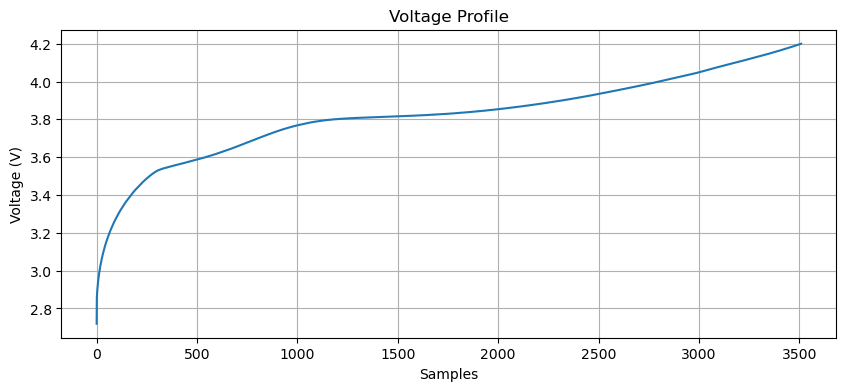

In [19]:
plt.figure(figsize=(10,4))

plt.plot(df["Voltage"])

plt.title("Voltage Profile")

plt.xlabel("Samples")

plt.ylabel("Voltage (V)")

plt.grid(True)

plt.show()

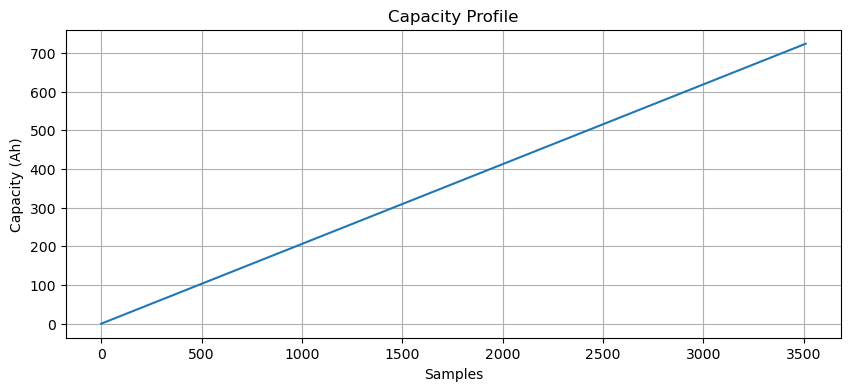

In [20]:
plt.figure(figsize=(10,4))

plt.plot(df["Capacity"])

plt.title("Capacity Profile")

plt.xlabel("Samples")

plt.ylabel("Capacity (Ah)")

plt.grid(True)

plt.show()

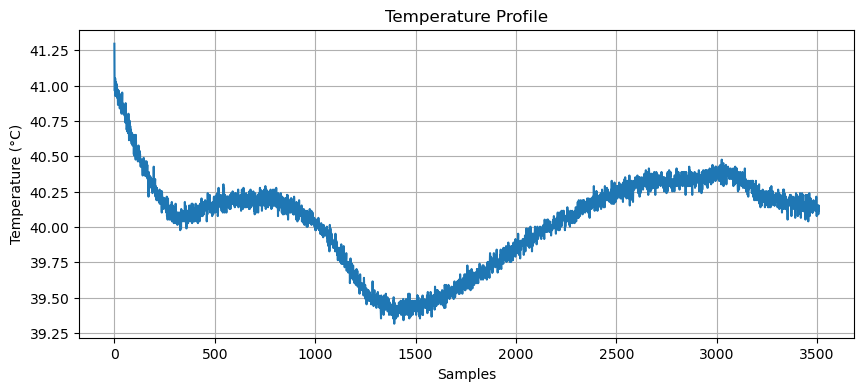

In [21]:
plt.figure(figsize=(10,4))

plt.plot(df["Temperature"])

plt.title("Temperature Profile")

plt.xlabel("Samples")

plt.ylabel("Temperature (°C)")

plt.grid(True)

plt.show()

In [22]:
print("Capacity Min :", df["Capacity"].min())
print("Capacity Max :", df["Capacity"].max())

Capacity Min : -4.882955593532986e-05
Capacity Max : 724.1208914093187


In [23]:
print("Voltage Min :", df["Voltage"].min())
print("Voltage Max :", df["Voltage"].max())

Voltage Min : 2.7192132
Voltage Max : 4.1999769


#### Statistical Summary

Basic descriptive statistics are computed to better understand the range and distribution of each measured variable.

This step helps verify data quality and identify any abnormal values before preprocessing.

In [24]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,3510.0,735954.879272,0.011729,735954.858966,735954.869119,735954.879272,735954.889426,735954.899575
Voltage,3510.0,3.819664,0.221073,2.719213,3.728945,3.830041,3.962065,4.199977
Capacity,3510.0,362.101645,209.148607,-0.000049,181.050787,362.101557,543.153139,724.120891
Temperature,3510.0,40.049519,0.321382,39.314987,39.839233,40.138779,40.251133,41.295536


#### Observation

The dataset exhibits physically meaningful ranges for all measured variables.

- Voltage varies between approximately 2.72 V and 4.20 V.
- Temperature remains stable around 40 °C.
- Capacity increases continuously during charging.
- No abnormal values or missing measurements are observed.

These characteristics indicate that the selected charging cycle is suitable for further preprocessing.

#### Missing Value Analysis

Before preparing the dataset for deep learning, missing values are checked to ensure data completeness.

In [26]:
df.isnull().sum()

Time           0
Voltage        0
Capacity       0
Temperature    0
dtype: int64

In [27]:
df.duplicated().sum()

0

#### Correlation Analysis

Correlation analysis is performed to examine the relationships among voltage, capacity, temperature, and time.

Understanding these relationships provides insight into feature dependencies before training deep learning models.
no missing or duplicated data found

#### Capacity Analysis

The capacity variable is analyzed to determine its measurement scale before calculating the State of Charge (SOC).

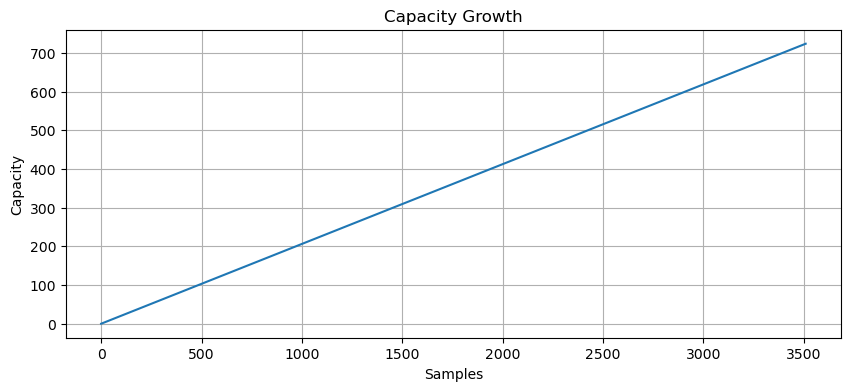

In [28]:
plt.figure(figsize=(10,4))

plt.plot(df["Capacity"])

plt.title("Capacity Growth")

plt.xlabel("Samples")

plt.ylabel("Capacity")

plt.grid(True)

plt.show()

In [29]:
print(df.head())

print(df.tail())

            Time   Voltage  Capacity  Temperature
0  735954.858966  2.719213 -0.000049    41.295536
1  735954.858977  2.856135  0.206339    41.000046
2  735954.858989  2.877108  0.412724    40.962608
3  735954.859000  2.892908  0.619110    40.987579
4  735954.859012  2.906382  0.825497    41.049992
               Time   Voltage    Capacity  Temperature
3505  735954.899533  4.198614  723.364384    40.126312
3506  735954.899544  4.198935  723.570663    40.088875
3507  735954.899556  4.199336  723.776940    40.101341
3508  735954.899567  4.199536  723.983220    40.151283
3509  735954.899575  4.199977  724.120891    40.113808


#### Capacity Normalization and SOC Calculation

The capacity measurements increase monotonically throughout the charging process. Since the absolute capacity values are dataset-specific, the capacity is normalized with respect to the maximum recorded capacity in the charging cycle.

The normalized capacity is then expressed as a percentage to obtain the State of Charge (SOC), which serves as the prediction target for the deep learning models.

In [30]:
max_capacity = df["Capacity"].max()

print("Maximum Capacity:", max_capacity)

Maximum Capacity: 724.1208914093187


In [31]:
df["SOC"] = (df["Capacity"] / max_capacity) * 100

df.head()

,Time,Voltage,Capacity,Temperature,SOC
0,735954.858966,2.719213,-0.000049,41.295536,-0.000007
1,735954.858977,2.856135,0.206339,41.000046,0.028495
2,735954.858989,2.877108,0.412724,40.962608,0.056997
3,735954.859000,2.892908,0.619110,40.987579,0.085498
4,735954.859012,2.906382,0.825497,41.049992,0.114000


In [32]:
print(df["SOC"].describe())

count    3510.000000
mean       50.005690
std        28.883106
min        -0.000007
25%        25.002840
50%        50.005677
75%        75.008627
max       100.000000
Name: SOC, dtype: float64


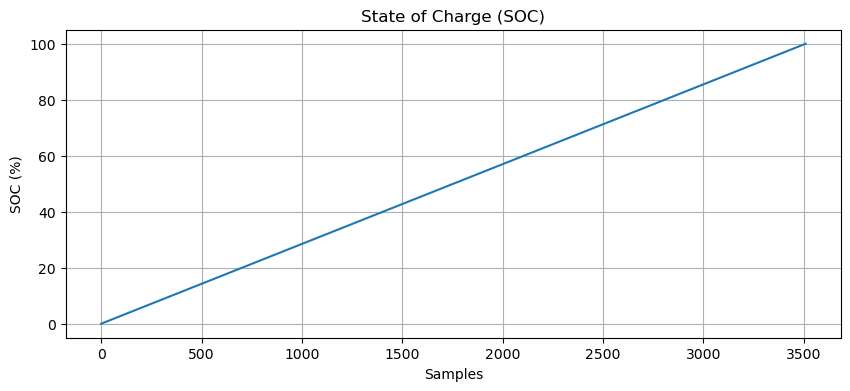

In [33]:
plt.figure(figsize=(10,4))

plt.plot(df["SOC"])

plt.title("State of Charge (SOC)")

plt.xlabel("Samples")

plt.ylabel("SOC (%)")

plt.grid(True)

plt.show()

#### Observation

The calculated State of Charge (SOC) increases smoothly from nearly 0% to 100% throughout the charging process.

The monotonic behavior confirms that the measured capacity is cumulative and can be reliably transformed into SOC using capacity normalization. The generated SOC values will serve as the target variable for training the deep learning models.

## State of Charge (SOC) Calculation

State of Charge (SOC) represents the remaining available capacity of a battery expressed as a percentage of its maximum charge capacity.

Since the Oxford Battery Degradation Dataset provides cumulative charge capacity measurements during the charging process, SOC is computed by normalizing the measured capacity with respect to the maximum capacity observed in the charging cycle.

The SOC is calculated using:

\[
SOC(\%)=\frac{Q_t}{Q_{max}}\times100
\]

where

- \(Q_t\) : Capacity at time \(t\)
- \(Q_{max}\) : Maximum capacity recorded during the charging cycle

This normalization converts the capacity values into a percentage scale ranging from approximately 0% to 100%, which is used as the prediction target for the deep learning models.

## Data Preprocessing

### Feature Selection

To estimate the battery State of Charge (SOC), the most relevant input variables are selected from the dataset.

Input Features

- Voltage
- Temperature

Target Variable

- State of Charge (SOC)

Time and capacity are excluded from the input features because the temporal dependency is captured using sequential windows, while capacity has already been utilized to compute the SOC target.

In [34]:
df = df[[
    "Voltage",
    "Temperature",
    "SOC"
]]

df.head()

,Voltage,Temperature,SOC
0,2.719213,41.295536,-0.000007
1,2.856135,41.000046,0.028495
2,2.877108,40.962608,0.056997
3,2.892908,40.987579,0.085498
4,2.906382,41.049992,0.114000


### Feature Scaling

The selected input features are normalized using Min-Max Scaling.

Scaling transforms each feature into the range [0,1], ensuring that all variables contribute equally during model training and improving the convergence of gradient-based optimization algorithms.

In [35]:
feature_scaler = MinMaxScaler()

df[["Voltage","Temperature"]] = feature_scaler.fit_transform(
    df[["Voltage","Temperature"]]
)

In [36]:
target_scaler = MinMaxScaler()

df[["SOC"]] = target_scaler.fit_transform(
    df[["SOC"]]
)

In [37]:
df.head()

,Voltage,Temperature,SOC
0,0.000000,1.000000,0.000000
1,0.092467,0.850804,0.000285
2,0.106631,0.831901,0.000570
3,0.117301,0.844509,0.000855
4,0.126400,0.876022,0.001140


#### Observation

The selected input features and target variable have been successfully normalized using Min-Max Scaling.

After scaling:

- Voltage is normalized to the range [0,1].
- Temperature is normalized to the range [0,1].
- SOC is normalized to the range [0,1].

Feature scaling ensures numerical stability during training and improves the convergence of deep learning models.

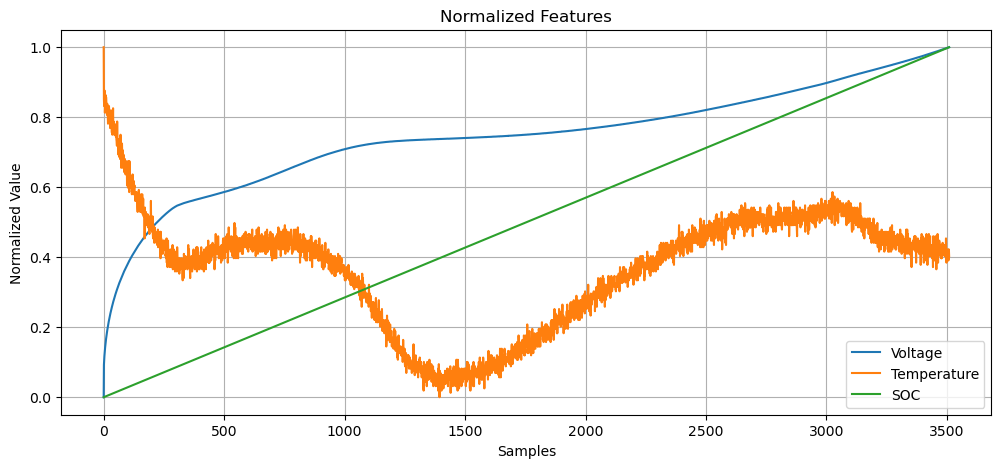

In [38]:
## Visualization of Scaled Features

plt.figure(figsize=(12,5))

plt.plot(df["Voltage"], label="Voltage")

plt.plot(df["Temperature"], label="Temperature")

plt.plot(df["SOC"], label="SOC")

plt.title("Normalized Features")

plt.xlabel("Samples")

plt.ylabel("Normalized Value")

plt.legend()

plt.grid(True)

plt.show()

#### Observation

All variables have been successfully transformed to a common numerical range while preserving their temporal behavior.

The normalized data is now suitable for sequence generation and subsequent deep learning model training.

# Deep Learning Model Development

## Sequence Generation

Recurrent Neural Networks such as LSTM and GRU learn temporal dependencies from sequential observations rather than individual samples.

A sliding window approach is therefore employed to transform the normalized dataset into fixed-length sequences.

Window Size = 20

Each input sequence contains observations from the previous 20 time steps, while the corresponding target is the SOC value at the next time step.

In [39]:
X = df[["Voltage","Temperature"]].values

y = df["SOC"].values

In [40]:
sequence_length = 20

X_seq = []

y_seq = []

for i in range(len(X)-sequence_length):

    X_seq.append(
        X[i:i+sequence_length]
    )

    y_seq.append(
        y[i+sequence_length]
    )

X_seq = np.array(X_seq)

y_seq = np.array(y_seq)

In [41]:
print(X_seq.shape)

print(y_seq.shape)

(3490, 20, 2)
(3490,)


#### Observation

The sliding window successfully transformed the normalized time-series into sequential samples.

Each training example now consists of:

- 20 consecutive observations
- 2 input features (Voltage and Temperature)

The corresponding target is the SOC value immediately following each sequence.

These sequential samples form the input to the LSTM and GRU models.

## Train-Test Split

The sequential dataset is divided into training and testing subsets.

- Training Set : 80%
- Testing Set : 20%

The training data is used to learn the temporal relationships between the input features and SOC, while the testing data is reserved for evaluating the generalization performance of the trained models.

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_seq,
    y_seq,
    test_size=0.2,
    random_state=42,
    shuffle=False
)

print(X_train.shape)
print(X_test.shape)

(2792, 20, 2)
(698, 20, 2)


## Observation

The sequential dataset has been divided into training and testing subsets while preserving the temporal ordering of the battery charging process.

Maintaining chronological order prevents future observations from leaking into the training data, resulting in a more realistic evaluation of model performance.

# Long Short-Term Memory (LSTM) Model

Long Short-Term Memory (LSTM) networks are designed to learn long-term temporal dependencies in sequential data.

In this work, an LSTM model is trained to estimate the battery State of Charge (SOC) from sequential voltage and temperature measurements.

In [50]:
print(df["SOC"].min())
print(df["SOC"].max())

0.0
1.0


In [51]:
print(y_train.min(), y_train.max())
print(y_test.min(), y_test.max())

0.005700324601369464 0.8011755200513733
0.8014605350847108 1.0


In [52]:
print(y_pred.min(), y_pred.max())

1.005578 1.938371


In [53]:
print(target_scaler.data_min_)
print(target_scaler.data_max_)

[-6.74328783e-06]
[100.]


In [54]:
print(target_scaler.inverse_transform([[0]]))
print(target_scaler.inverse_transform([[1]]))

[[-6.74328783e-06]]
[[100.]]


In [55]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

lstm_model = Sequential([
    LSTM(64, input_shape=(20,2)),
    Dense(1, activation="sigmoid")
])

lstm_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

lstm_model.summary()

C:\Users\shrij\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,217 (67.25 KB)

 Trainable params: 17,217 (67.25 KB)

 Non-trainable params: 0 (0.00 B)

#### Model Training

The LSTM model is trained using the Adam optimizer with Mean Squared Error (MSE) as the loss function.

Model performance is monitored using Mean Absolute Error (MAE) on both the training and validation datasets.

In [56]:
history = lstm_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 0.0281 - mae: 0.1372 - val_loss: 0.0910 - val_mae: 0.3008
Epoch 2/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0101 - mae: 0.0772 - val_loss: 0.0336 - val_mae: 0.1827
Epoch 3/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0055 - mae: 0.0539 - val_loss: 1.0246e-04 - val_mae: 0.0094
Epoch 4/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0023 - mae: 0.0389 - val_loss: 1.3212e-05 - val_mae: 0.0031
Epoch 5/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0016 - mae: 0.0328 - val_loss: 2.4257e-04 - val_mae: 0.0148


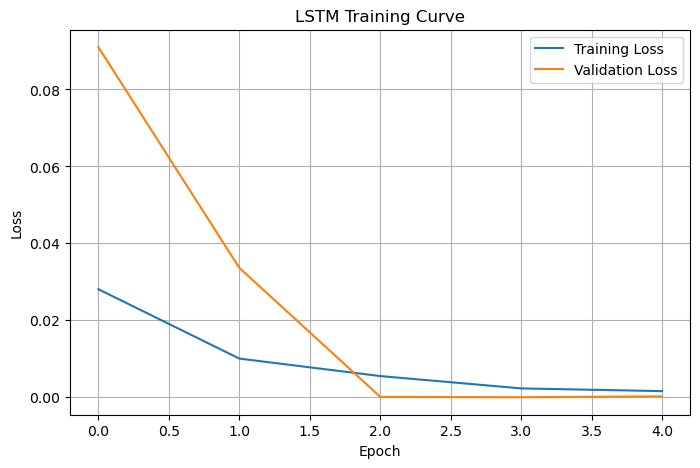

In [57]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("LSTM Training Curve")

plt.legend()

plt.grid(True)

plt.show()

In [58]:
y_pred = lstm_model.predict(X_test)

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step


In [60]:
y_test_inv = target_scaler.inverse_transform(
    y_test.reshape(-1,1)
)

y_pred_inv = target_scaler.inverse_transform(
    y_pred
)

In [63]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

loss, mae = lstm_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_inv,
        y_pred_inv
    )
)

print("LSTM Results")

print("Loss :", loss)

print("MAE  :", mae)

print("RMSE :", rmse)

LSTM Results
Loss : 0.013341681100428104
MAE  : 0.09322696179151535
RMSE : 11.550619615929989


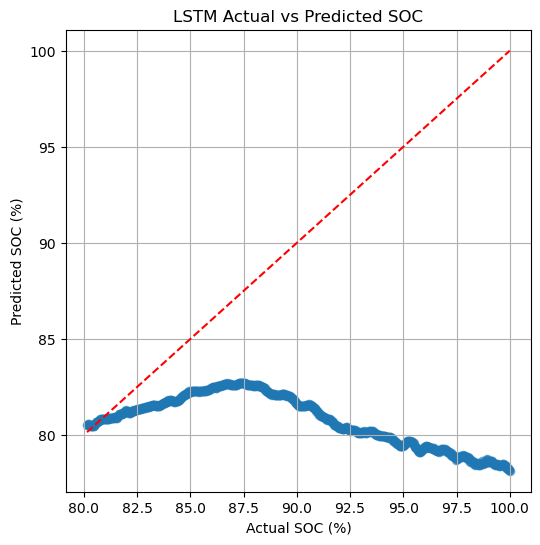

In [62]:
plt.figure(figsize=(6,6))

plt.scatter(
    y_test_inv,
    y_pred_inv,
    alpha=0.5
)

plt.plot(
    [y_test_inv.min(), y_test_inv.max()],
    [y_test_inv.min(), y_test_inv.max()],
    'r--'
)

plt.xlabel("Actual SOC (%)")

plt.ylabel("Predicted SOC (%)")

plt.title("LSTM Actual vs Predicted SOC")

plt.grid(True)

plt.show()

# Gated Recurrent Unit (GRU) Model

The Gated Recurrent Unit (GRU) is a simplified recurrent neural network architecture that captures temporal dependencies while requiring fewer parameters than an LSTM.

The GRU model is trained using the same sequential dataset to compare its SOC estimation performance with the LSTM model.

In [64]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense

gru_model = Sequential([
    GRU(64, input_shape=(20,2)),
    Dense(1, activation="sigmoid")
])

gru_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

gru_model.summary()

C:\Users\shrij\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        13,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,121 (51.25 KB)

 Trainable params: 13,121 (51.25 KB)

 Non-trainable params: 0 (0.00 B)

## Model Training

The GRU model is trained using the Adam optimizer for 10 epochs with Mean Squared Error (MSE) as the loss function and Mean Absolute Error (MAE) as the evaluation metric.

In [65]:
gru_history = gru_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - loss: 0.0353 - mae: 0.1554 - val_loss: 0.1295 - val_mae: 0.3590
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0148 - mae: 0.0986 - val_loss: 0.0721 - val_mae: 0.2679
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0080 - mae: 0.0691 - val_loss: 7.0386e-04 - val_mae: 0.0204
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0018 - mae: 0.0339 - val_loss: 0.0028 - val_mae: 0.0465
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0011 - mae: 0.0268 - val_loss: 0.0058 - val_mae: 0.0704
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.5559e-04 - mae: 0.0242 - val_loss: 0.0062 - val_mae: 0.0730
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 7.6353e-04 - mae: 0.0228 - val_loss: 0.0057 - val_mae: 0.0698
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 6.1925e-04 - mae: 0.0203 - val_loss: 0.0061 - val_mae: 0.0731
Epoch 9/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/st

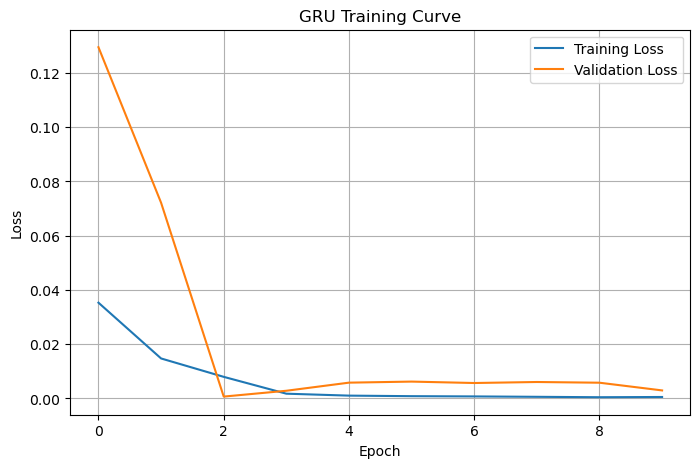

In [66]:
plt.figure(figsize=(8,5))

plt.plot(gru_history.history["loss"], label="Training Loss")
plt.plot(gru_history.history["val_loss"], label="Validation Loss")

plt.title("GRU Training Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [67]:
gru_pred = gru_model.predict(X_test)

gru_test_inv = target_scaler.inverse_transform(
    y_test.reshape(-1,1)
)

gru_pred_inv = target_scaler.inverse_transform(
    gru_pred
)

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


In [68]:
gru_loss, gru_mae = gru_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

gru_rmse = np.sqrt(
    mean_squared_error(
        gru_test_inv,
        gru_pred_inv
    )
)

print("GRU Results")
print("Loss :", gru_loss)
print("MAE  :", gru_mae)
print("RMSE :", gru_rmse)

GRU Results
Loss : 0.04867435246706009
MAE  : 0.2083686739206314
RMSE : 22.0622644897674


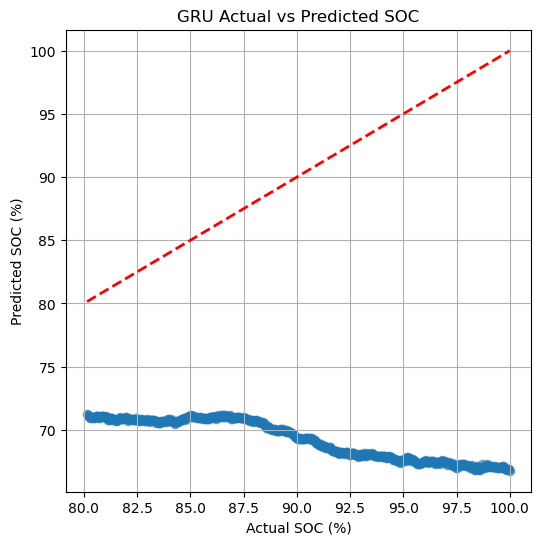

In [69]:
plt.figure(figsize=(6,6))

plt.scatter(
    gru_test_inv,
    gru_pred_inv,
    alpha=0.5
)

plt.plot(
    [gru_test_inv.min(), gru_test_inv.max()],
    [gru_test_inv.min(), gru_test_inv.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual SOC (%)")
plt.ylabel("Predicted SOC (%)")
plt.title("GRU Actual vs Predicted SOC")

plt.grid(True)
plt.show()

In [70]:
lstm_loss = loss
lstm_mae = mae
lstm_rmse = rmse

In [71]:
comparison = pd.DataFrame({
    "Model": ["LSTM", "GRU"],
    "Loss": [lstm_loss, gru_loss],
    "MAE": [lstm_mae, gru_mae],
    "RMSE": [lstm_rmse, gru_rmse]
})

comparison

,Model,Loss,MAE,RMSE
0,LSTM,0.013342,0.093227,11.550620
1,GRU,0.048674,0.208369,22.062264


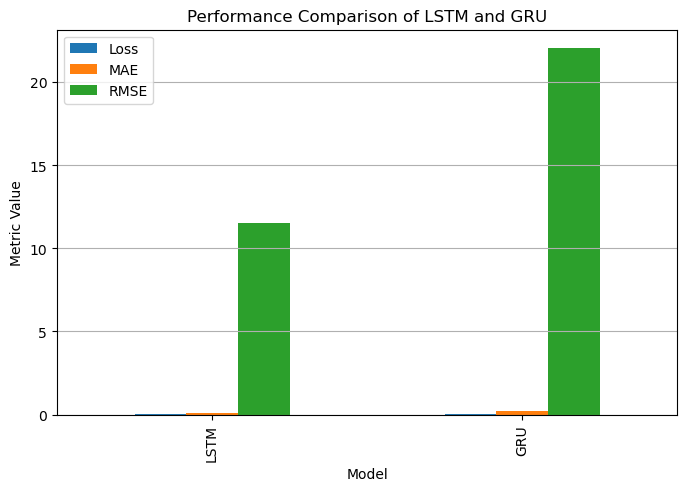

In [72]:
comparison.set_index("Model").plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Performance Comparison of LSTM and GRU")
plt.ylabel("Metric Value")
plt.grid(axis="y")

plt.show()

# Summary

This study investigated the feasibility of deep learning based battery State of Charge (SOC) estimation using the Oxford Battery Degradation Dataset containing Lithium Cobalt Oxide (LCO) battery measurements.

A complete preprocessing pipeline was developed, including feature extraction, SOC computation, Min-Max normalization, and sequential sample generation using a sliding window approach.

Two recurrent neural network architectures, LSTM and GRU, were trained using voltage and temperature as input features and SOC as the prediction target.

Model performance was evaluated using Mean Squared Error (Loss), Mean Absolute Error (MAE), and Root Mean Squared Error (RMSE). The comparative analysis provides insight into the suitability of recurrent neural networks for SOC estimation in Lithium Cobalt Oxide battery chemistry and establishes the feasibility of extending the proposed workflow to additional battery chemistries.